In [17]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [18]:
path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")

def load_sensor(filepath):
    return pd.read_csv(filepath, sep='\t', header=None).values

SENSOR_LIST = ['PS1', 'PS2', 'PS3', 'TS1', 'TS2']

sensor_data = {}
for s in SENSOR_LIST:
    sensor_data[s] = load_sensor(os.path.join(path, f"{s}.txt"))
    print(f"   {s:5s} → shape: {sensor_data[s].shape}")

profile = pd.read_csv(os.path.join(path, 'profile.txt'), sep='\t', header=None)
profile.columns = ['cooler_cond', 'valve_cond', 'pump_leak',
                   'accumulator_cond', 'stable_flag']

print(f"\n{sensor_data['PS1'].shape[0]} siklus operasi berhasil dimuat.")
print(profile.head())


   PS1   → shape: (2205, 6000)
   PS2   → shape: (2205, 6000)
   PS3   → shape: (2205, 6000)
   TS1   → shape: (2205, 60)
   TS2   → shape: (2205, 60)

2205 siklus operasi berhasil dimuat.
   cooler_cond  valve_cond  pump_leak  accumulator_cond  stable_flag
0            3         100          0               130            1
1            3         100          0               130            1
2            3         100          0               130            1
3            3         100          0               130            1
4            3         100          0               130            1


In [19]:
feature_dict = {}
for s in SENSOR_LIST:
    d = sensor_data[s]
    feature_dict[f'{s}_mean'] = d.mean(axis=1)
    feature_dict[f'{s}_std']  = d.std(axis=1)

X = pd.DataFrame(feature_dict)
print(f"Matriks Fitur : {X.shape}  ({X.shape[0]} siklus × {X.shape[1]} fitur)")
print(X.describe().round(4))

Matriks Fitur : (2205, 10)  (2205 siklus × 10 fitur)
        PS1_mean    PS1_std   PS2_mean    PS2_std   PS3_mean    PS3_std  \
count  2205.0000  2205.0000  2205.0000  2205.0000  2205.0000  2205.0000   
mean    160.4853    15.2949   109.3799    47.7322     1.7532     0.8993   
std       4.6994     2.0679     4.9866     3.2717     0.2519     0.0398   
min     155.3915    13.9265   104.4063    45.2032     0.8403     0.7284   
25%     158.1002    14.1434   106.9624    46.2058     1.7297     0.8686   
50%     158.9609    14.7297   107.7302    46.8021     1.7796     0.8874   
75%     161.0007    15.0489   109.4216    47.2036     1.9320     0.9335   
max     180.9227    22.1399   131.5891    59.5483     2.0234     1.0492   

        TS1_mean    TS1_std   TS2_mean    TS2_std  
count  2205.0000  2205.0000  2205.0000  2205.0000  
mean     45.4246     0.1913    50.3660     0.1133  
std       7.9919     0.0443     7.3963     0.0472  
min      35.3138     0.0603    40.8594     0.0362  
25%      36

Distribusi kelas (pump_leak):
   Kelas 0: 1221 sampel (55.4%)
   Kelas 1: 492 sampel (22.3%)
   Kelas 2: 492 sampel (22.3%)


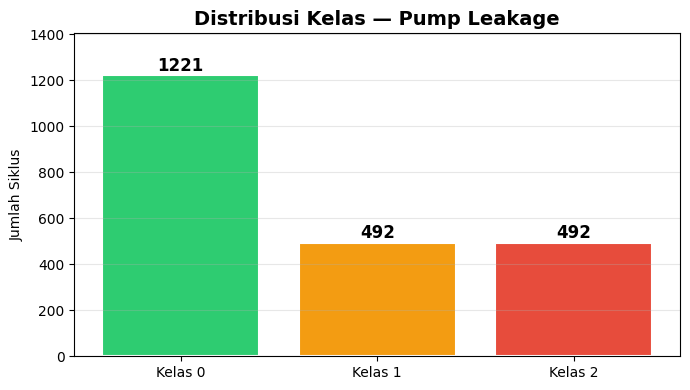

In [20]:
y_raw = profile['pump_leak'].values

le = LabelEncoder()
y  = le.fit_transform(y_raw)
n_classes   = len(le.classes_)
class_names = [f"Kelas {c}" for c in le.classes_]

print("Distribusi kelas (pump_leak):")
unique, counts = np.unique(y_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   Kelas {u}: {c} sampel ({c/len(y_raw)*100:.1f}%)")

# Plot distribusi
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar([f"Kelas {u}" for u in unique], counts,
              color=colors, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Distribusi Kelas — Pump Leakage', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Siklus')
ax.set_ylim(0, max(counts) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

| Nilai | Arti |
|-------|------|
| 0 | Tidak ada kebocoran (Normal) |
| 1 | Kebocoran lemah |
| 2 | Kebocoran parah |

In [21]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

unique_cls, cls_counts = np.unique(y_train, return_counts=True)
n_total   = len(y_train)
n_classes_tmp = len(unique_cls)

class_weights_np = n_total / (n_classes_tmp * cls_counts)
class_weights    = torch.FloatTensor(class_weights_np).to(DEVICE)

print(f"Data dibagi:")
print(f"   Train : {X_train.shape[0]} sampel")
print(f"   Test  : {X_test.shape[0]} sampel")
print(f"   Fitur : {X_train.shape[1]}")
print(f"\nClass Weights (inverse frequency):")
for c, w, cnt in zip(unique_cls, class_weights_np, cls_counts):
    print(f"   Kelas {c}: {cnt:4d} sampel → weight = {w:.4f}")

Data dibagi:
   Train : 1764 sampel
   Test  : 441 sampel
   Fitur : 10

Class Weights (inverse frequency):
   Kelas 0:  977 sampel → weight = 0.6018
   Kelas 1:  393 sampel → weight = 1.4962
   Kelas 2:  394 sampel → weight = 1.4924


### Subtractive Clustering
Menemukan pusat klaster secara otomatis, tiap klaster = satu aturan fuzzy di ANFIS.

In [22]:
class SubtractiveClustering:
    def __init__(self, ra=0.5, squash_factor=1.5,
                 accept_ratio=0.5, reject_ratio=0.15):
        self.ra           = ra
        self.rb           = ra * squash_factor
        self.accept_ratio = accept_ratio
        self.reject_ratio = reject_ratio

    def fit(self, X):
        X   = np.array(X, dtype=np.float64)
        n, d = X.shape

        self.x_min_ = X.min(axis=0)
        self.x_max_ = X.max(axis=0)
        Xn = (X - self.x_min_) / (self.x_max_ - self.x_min_ + 1e-10)

        alpha = 4.0 / self.ra ** 2
        beta  = 4.0 / self.rb ** 2

        potential = np.array([
            np.exp(-alpha * ((Xn - Xn[i])**2).sum(axis=1)).sum()
            for i in range(n)
        ])

        centers, sigmas = [], []
        p_first = potential.max()

        for _ in range(30):
            idx = np.argmax(potential)
            pc  = potential[idx]
            xc  = Xn[idx].copy()

            if len(centers) == 0:
                accept = True
            else:
                d_min = min(np.linalg.norm(xc - c) for c in centers)
                if   pc >= self.accept_ratio * p_first: accept = True
                elif pc <  self.reject_ratio * p_first: break
                elif (d_min / self.ra) + (pc / p_first) >= 1.0: accept = True
                else:
                    potential[idx] = 0.0
                    continue

            if accept:
                centers.append(xc)
                sigmas.append(self.ra / 2.0)
                dist_sq    = ((Xn - xc)**2).sum(axis=1)
                potential -= pc * np.exp(-beta * dist_sq)

        centers_denorm = np.array(centers) * (self.x_max_ - self.x_min_) + self.x_min_
        self.centers_ = centers_denorm          # (n_rules, n_feat) Z-score scale

        self.sigmas_  = np.array(sigmas).reshape(-1,1) * np.ones((len(centers), d))
        return self

    @property
    def n_rules_(self): return len(self.centers_)

sc      = SubtractiveClustering(ra=0.5)
sc.fit(X_train)

n_rules  = sc.n_rules_
n_inputs = X_train.shape[1]

print(f"Jumlah aturan (rules) terbentuk : {n_rules}")
print(f"Dimensi fitur input             : {n_inputs}")

centers_df = pd.DataFrame(
    sc.centers_, columns=X.columns,
    index=[f"Rule {i+1}" for i in range(n_rules)]
)
print(f"\nPusat Klaster (ruang Z-score):")
print(centers_df.round(4))

Jumlah aturan (rules) terbentuk : 4
Dimensi fitur input             : 10

Pusat Klaster (ruang Z-score):
        PS1_mean  PS1_std  PS2_mean  PS2_std  PS3_mean  PS3_std  TS1_mean  \
Rule 1    0.0367  -0.6322    0.0071  -0.1975    0.7921   0.7908   -1.1815   
Rule 2   -0.4735  -0.2820   -0.4268  -0.4143   -0.0375  -0.6418    0.0508   
Rule 3   -0.7756  -0.0726   -0.6945  -0.5753    0.0257  -0.6979    1.2056   
Rule 4    2.6044   2.9210    2.7002   2.7652   -2.6362   1.4564    1.4527   

        TS1_std  TS2_mean  TS2_std  
Rule 1  -0.9521   -1.1907  -1.0390  
Rule 2   0.0393    0.0468  -0.1611  
Rule 3   0.9971    1.2537   0.5897  
Rule 4   0.1871    1.3706   1.2898  


### Arsitektur Model ANFIS (PyTorch)

Arsitektur:

- L1: Fuzzifikasi
- L2: Rule
- L3: Normalisasi      
- L4: Defuzzifikasi
- L5: Output

In [23]:
class ANFIS(nn.Module):
    def __init__(self, n_inputs, n_rules, n_classes):
        super().__init__()
        self.n_inputs  = n_inputs
        self.n_rules   = n_rules
        self.n_classes = n_classes

        # L1 — Gaussian MF: mean & sigma, shape (n_rules, n_inputs)
        self.mf_mean  = nn.Parameter(torch.randn(n_rules, n_inputs))
        self.mf_sigma = nn.Parameter(torch.ones(n_rules, n_inputs) * 0.5)

        # L4-L5 — Konsekuen linear → logits [n_classes]
        # Dimensi input: n_rules * (n_inputs + 1)  [wx-terms + w_norm terms]
        self.consequent = nn.Linear(n_rules * (n_inputs + 1), n_classes)

    # Inisialisasi dari hasil Subtractive Clustering
    def init_from_sc(self, centers_norm, sigmas_norm):
        with torch.no_grad():
            self.mf_mean.data  = torch.FloatTensor(centers_norm)
            self.mf_sigma.data = torch.FloatTensor(sigmas_norm)

    def forward(self, x):
        B  = x.size(0)
        R  = self.n_rules
        ni = self.n_inputs

        # L1: Gaussian μ = exp(-((x - c) / σ)²)
        x_exp  = x.unsqueeze(1).expand(B, R, ni)              # (B, R, ni)
        mu_exp = self.mf_mean.unsqueeze(0)                    # (1, R, ni)
        sg_exp = torch.abs(self.mf_sigma).unsqueeze(0) + 1e-6 # (1, R, ni)
        gauss  = torch.exp(-((x_exp - mu_exp) / sg_exp) ** 2) # (B, R, ni)

        # L2: Firing strength = produk MF tiap aturan
        w = gauss.prod(dim=2)                                  # (B, R)

        # L3: Normalisasi firing strength
        w_norm = w / (w.sum(dim=1, keepdim=True) + 1e-10)     # (B, R)

        # L4: Konsekuen Takagi-Sugeno: w̄_r * x_i  (semua r, i)
        w_exp  = w_norm.unsqueeze(2).expand(B, R, ni)         # (B, R, ni)
        x_exp2 = x.unsqueeze(1).expand(B, R, ni)              # (B, R, ni)
        wx     = (w_exp * x_exp2).reshape(B, -1)              # (B, R*ni)
        feat   = torch.cat([wx, w_norm], dim=1)               # (B, R*(ni+1))

        # L5: Raw logits (TANPA softmax — CrossEntropyLoss tangani sendiri)
        return self.consequent(feat)                           # (B, n_classes)

    def predict_proba(self, x):
        """Kembalikan probabilitas Softmax secara eksplisit untuk evaluasi."""
        with torch.no_grad():
            logits = self.forward(x)
            return torch.softmax(logits, dim=1)

    def predict(self, x):
        """Prediksi kelas = argmax(logits)."""
        with torch.no_grad():
            return self.forward(x).argmax(dim=1)


model = ANFIS(n_inputs=n_inputs, n_rules=n_rules, n_classes=n_classes).to(DEVICE)
model.init_from_sc(sc.centers_, sc.sigmas_)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ANFIS berhasil dibuat.")
print(f"n_inputs   : {n_inputs}")
print(f"n_rules    : {n_rules}")
print(f"n_classes  : {n_classes}")
print(f"Total param: {n_params}")
print(model)

Model ANFIS berhasil dibuat.
n_inputs   : 10
n_rules    : 4
n_classes  : 3
Total param: 215
ANFIS(
  (consequent): Linear(in_features=44, out_features=3, bias=True)
)


In [24]:
X_tr_t = torch.FloatTensor(X_train).to(DEVICE)
y_tr_t = torch.LongTensor(y_train).to(DEVICE)
X_te_t = torch.FloatTensor(X_test).to(DEVICE)
y_te_t = torch.LongTensor(y_test).to(DEVICE)

BATCH_SIZE   = 32
train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=BATCH_SIZE, shuffle=True
)

optimizer = optim.Adam([
    {'params': [model.mf_mean, model.mf_sigma], 'lr': 5e-3},
    {'params': model.consequent.parameters(),    'lr': 1e-2},
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200, eta_min=1e-5)

criterion = nn.CrossEntropyLoss(weight=class_weights)

N_EPOCHS = 200
history  = {'loss': [], 'train_acc': [], 'val_acc': []}
best_val, best_state = 0.0, None

print("=" * 60)
print("   FASE 2 : GRADIENT-BASED MULTI-LR TRAINING")
print("=" * 60)

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_loss, correct, total = 0.0, 0, 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        correct    += logits.argmax(1).eq(yb).sum().item()
        total      += yb.size(0)

    scheduler.step()

    tr_loss = epoch_loss / len(train_loader)
    tr_acc  = correct / total

    model.eval()
    with torch.no_grad():
        val_acc = model.predict(X_te_t).eq(y_te_t).float().mean().item()

    history['loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val:
        best_val   = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 25 == 0:
        print(f"Epoch [{epoch:3d}/{N_EPOCHS}]  "
              f"Loss: {tr_loss:.4f}  "
              f"Train: {tr_acc*100:.2f}%  "
              f"Val: {val_acc*100:.2f}%")

model.load_state_dict(best_state)
print(f"\nBest Val Accuracy: {best_val*100:.2f}%")


   FASE 2 : GRADIENT-BASED MULTI-LR TRAINING
Epoch [ 25/200]  Loss: 0.4649  Train: 84.58%  Val: 88.21%
Epoch [ 50/200]  Loss: 0.3591  Train: 88.38%  Val: 90.25%
Epoch [ 75/200]  Loss: 0.3049  Train: 89.97%  Val: 90.02%
Epoch [100/200]  Loss: 0.2624  Train: 92.23%  Val: 92.06%
Epoch [125/200]  Loss: 0.2331  Train: 92.97%  Val: 91.61%
Epoch [150/200]  Loss: 0.2224  Train: 93.25%  Val: 92.74%
Epoch [175/200]  Loss: 0.2156  Train: 93.88%  Val: 92.97%
Epoch [200/200]  Loss: 0.2142  Train: 93.99%  Val: 92.97%

Best Val Accuracy: 93.20%


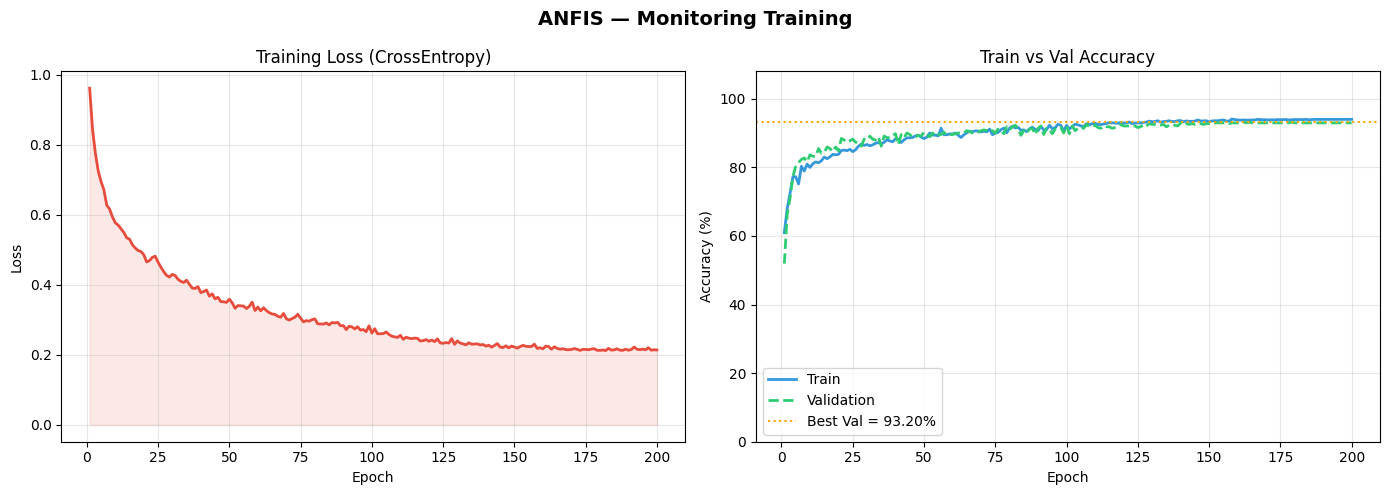

In [25]:
ep = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(ep, history['loss'], color='#e74c3c', lw=2)
ax1.fill_between(ep, history['loss'], alpha=0.12, color='#e74c3c')
ax1.set(xlabel='Epoch', ylabel='Loss', title='Training Loss (CrossEntropy)')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(ep, [a*100 for a in history['train_acc']], color='#3498db', lw=2, label='Train')
ax2.plot(ep, [a*100 for a in history['val_acc']],   color='#2ecc71', lw=2, ls='--', label='Validation')
ax2.axhline(y=best_val*100, color='orange', ls=':', lw=1.5, label=f'Best Val = {best_val*100:.2f}%')
ax2.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Train vs Val Accuracy', ylim=(0, 108))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('ANFIS — Monitoring Training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
model.eval()

# Prediksi kelas → argmax(logits)
y_pred   = model.predict(X_te_t).cpu().numpy()

# Probabilitas kelas → softmax(logits) secara EKSPLISIT
y_proba  = model.predict_proba(X_te_t).cpu().numpy()   # (n_test, n_classes)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print("=" * 62)
print("   EVALUASI GLOBAL")
print("=" * 62)
print(f"\n  Accuracy (keseluruhan)   : {acc*100:.4f}%")
print(f"  F1-Score (weighted)      : {f1*100:.4f}%")
print(f"  Jumlah Rules (aturan)    : {n_rules}")
print(f"  Jumlah Fitur Input       : {n_inputs}")
print()
print(classification_report(y_test, y_pred, target_names=class_names))

# Tampilkan 5 contoh probabilitas Softmax
print("\nContoh Probabilitas Softmax (5 sampel pertama test set):")
prob_df = pd.DataFrame(y_proba[:5].round(4), columns=class_names)
prob_df['Prediksi']  = [class_names[p] for p in y_pred[:5]]
prob_df['Aktual']    = [class_names[t] for t in y_test[:5]]
print(prob_df.to_string(index=False))

   EVALUASI GLOBAL

  Accuracy (keseluruhan)   : 93.1973%
  F1-Score (weighted)      : 93.2764%
  Jumlah Rules (aturan)    : 4
  Jumlah Fitur Input       : 10

              precision    recall  f1-score   support

     Kelas 0       0.99      0.95      0.97       244
     Kelas 1       0.91      0.87      0.89        99
     Kelas 2       0.84      0.94      0.88        98

    accuracy                           0.93       441
   macro avg       0.91      0.92      0.91       441
weighted avg       0.94      0.93      0.93       441


Contoh Probabilitas Softmax (5 sampel pertama test set):
 Kelas 0  Kelas 1  Kelas 2 Prediksi  Aktual
  0.9551   0.0449   0.0000  Kelas 0 Kelas 0
  0.0001   0.1771   0.8229  Kelas 2 Kelas 2
  0.9748   0.0252   0.0000  Kelas 0 Kelas 0
  0.0000   0.0304   0.9696  Kelas 2 Kelas 2
  0.1868   0.8132   0.0000  Kelas 1 Kelas 1


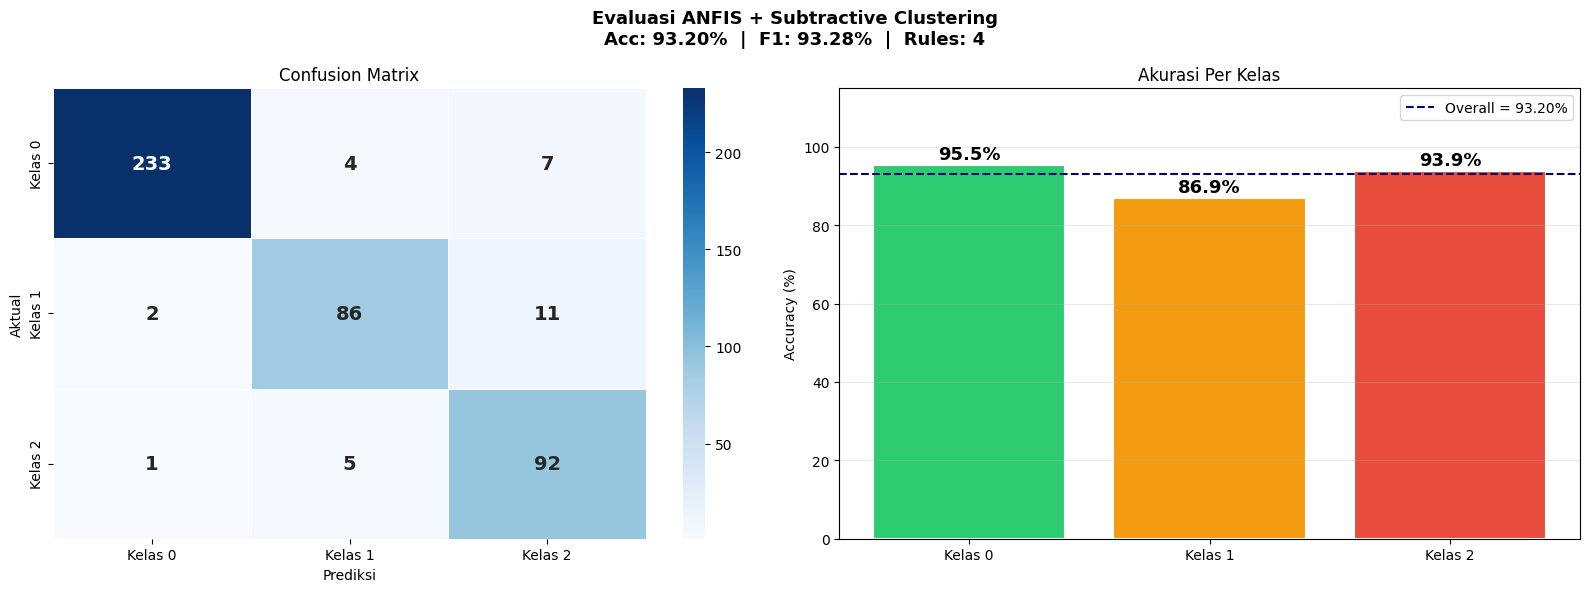

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, annot_kws={'size': 14, 'weight': 'bold'}, ax=ax1)
ax1.set(xlabel='Prediksi', ylabel='Aktual', title='Confusion Matrix')

per_class = cm.diagonal() / cm.sum(axis=1) * 100
ax2 = axes[1]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax2.bar(class_names, per_class, color=colors[:n_classes],
               edgecolor='white', lw=1.5)
for bar, v in zip(bars, per_class):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)
ax2.axhline(y=acc*100, color='navy', ls='--', lw=1.5,
            label=f'Overall = {acc*100:.2f}%')
ax2.set(ylabel='Accuracy (%)', title='Akurasi Per Kelas', ylim=(0, 115))
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle(f'Evaluasi ANFIS + Subtractive Clustering\n'
             f'Acc: {acc*100:.2f}%  |  F1: {f1*100:.2f}%  |  Rules: {n_rules}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

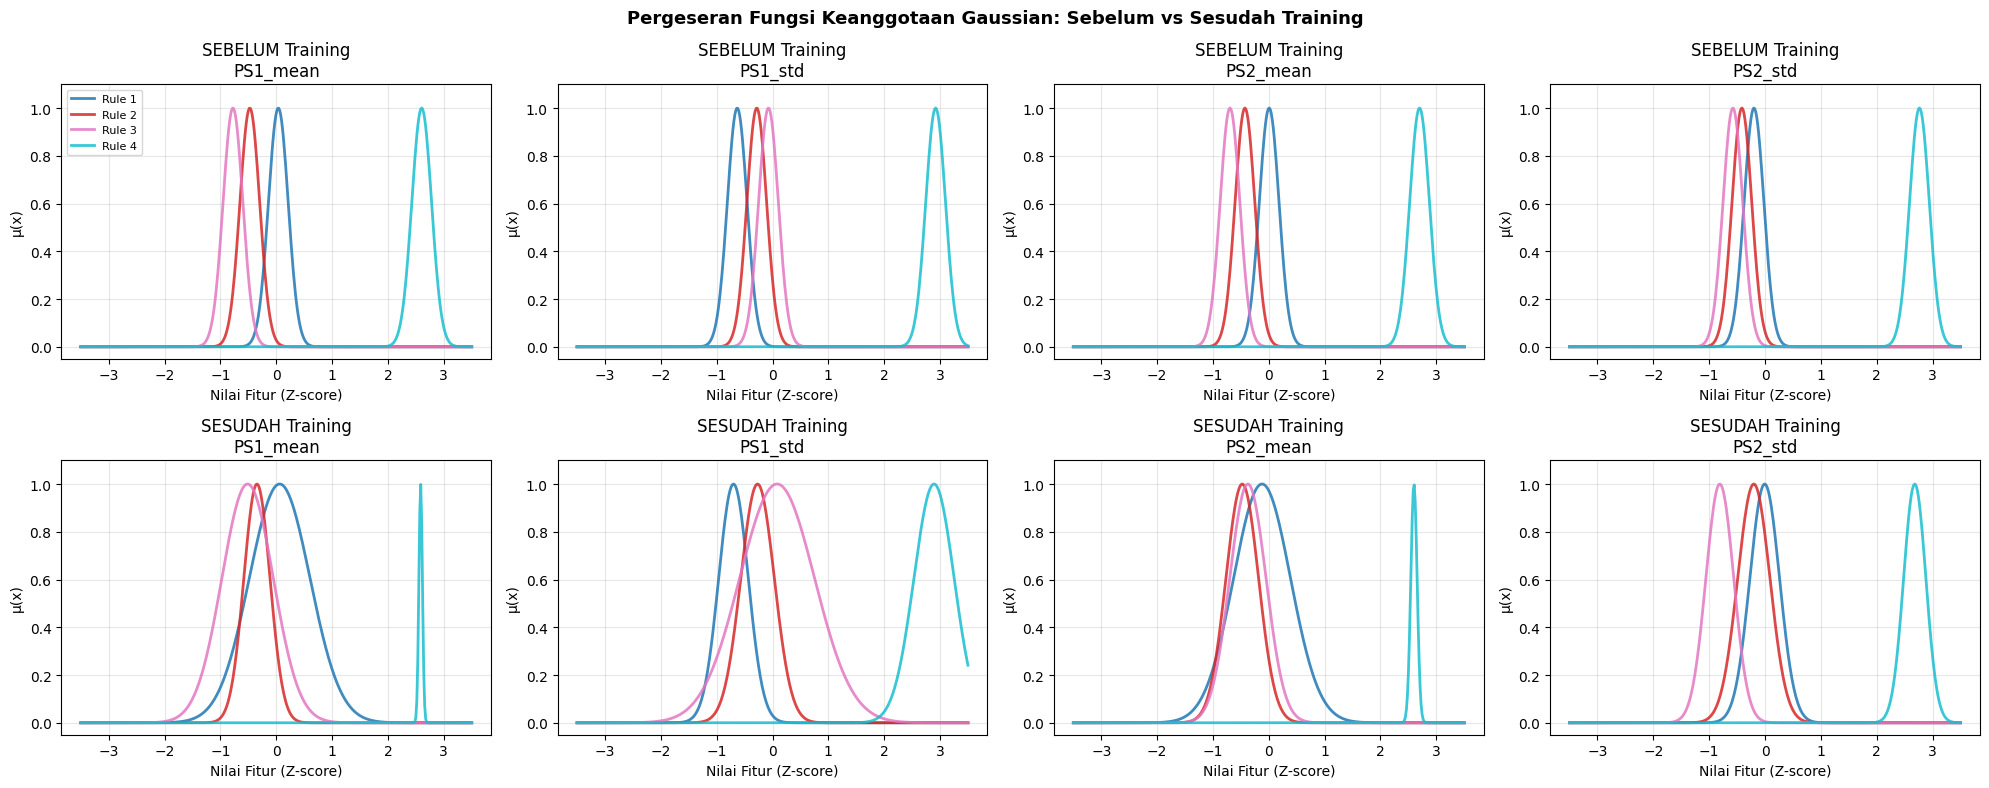

In [28]:
mf_mean_before  = sc.centers_
mf_sigma_before = sc.sigmas_

mf_mean_after   = model.mf_mean.detach().cpu().numpy()
mf_sigma_after  = np.abs(model.mf_sigma.detach().cpu().numpy()) + 1e-6

n_feat_show = min(4, n_inputs)
fig, axes = plt.subplots(2, n_feat_show, figsize=(5 * n_feat_show, 8))

if n_feat_show == 1:
    axes = axes.reshape(2, 1)

colors_r = plt.cm.tab10(np.linspace(0, 1, n_rules))
x_range  = np.linspace(-3.5, 3.5, 400)

for fi in range(n_feat_show):
    feat_name = list(X.columns)[fi]

    for row, (means, sigmas, title) in enumerate([
        (mf_mean_before, mf_sigma_before, f'SEBELUM Training\n{feat_name}'),
        (mf_mean_after,  mf_sigma_after,  f'SESUDAH Training\n{feat_name}')
    ]):
        ax = axes[row][fi]
        for ri in range(n_rules):
            mf = np.exp(-((x_range - means[ri, fi]) / sigmas[ri, fi])**2)
            ax.plot(x_range, mf, color=colors_r[ri], lw=2,
                    label=f'Rule {ri+1}', alpha=0.85)
        ax.set(title=title, xlabel='Nilai Fitur (Z-score)',
               ylabel='μ(x)', ylim=(-0.05, 1.1))
        ax.grid(True, alpha=0.3)
        if fi == 0 and row == 0:
            ax.legend(fontsize=8)

plt.suptitle('Pergeseran Fungsi Keanggotaan Gaussian: Sebelum vs Sesudah Training',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('membership_functions.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
cm_final = confusion_matrix(y_test, y_pred)
per_class_acc = (cm_final.diagonal() / cm_final.sum(axis=1) * 100).round(4)

summary = {
    'Dataset'            : 'Condition Monitoring Hydraulic Systems',
    'Target'             : 'pump_leak (3 kelas)',
    'Sensor Input'       : ', '.join(SENSOR_LIST),
    'Jumlah Fitur'       : n_inputs,
    'ra Subtractive SC'  : 0.5,
    'Jumlah Rules'       : n_rules,
    'Metode Optimizer'   : 'Adam (Multi-LR: MF=5e-3, Konsekuen=1e-2)',
    'Epochs'             : N_EPOCHS,
    'Accuracy (%)'       : round(acc * 100, 4),
    'F1-Score Weighted (%)': round(f1 * 100, 4),
    **{f'Acc {class_names[i]} (%)': per_class_acc[i] for i in range(n_classes)}
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['Nilai']
summary_df.index.name = 'Parameter'

print(summary_df.to_string())

                                                          Nilai
Parameter                                                      
Dataset                  Condition Monitoring Hydraulic Systems
Target                                      pump_leak (3 kelas)
Sensor Input                            PS1, PS2, PS3, TS1, TS2
Jumlah Fitur                                                 10
ra Subtractive SC                                           0.5
Jumlah Rules                                                  4
Metode Optimizer       Adam (Multi-LR: MF=5e-3, Konsekuen=1e-2)
Epochs                                                      200
Accuracy (%)                                            93.1973
F1-Score Weighted (%)                                   93.2764
Acc Kelas 0 (%)                                         95.4918
Acc Kelas 1 (%)                                         86.8687
Acc Kelas 2 (%)                                         93.8776
